# Mathematical Transformer

we apply mathematical formula on column  to transform it .



Some machine learning algorithm  perform better on normal data so if we work with them we need
to convert our data into normal distribution . 
    we convert them by transformation

# Function Transformer
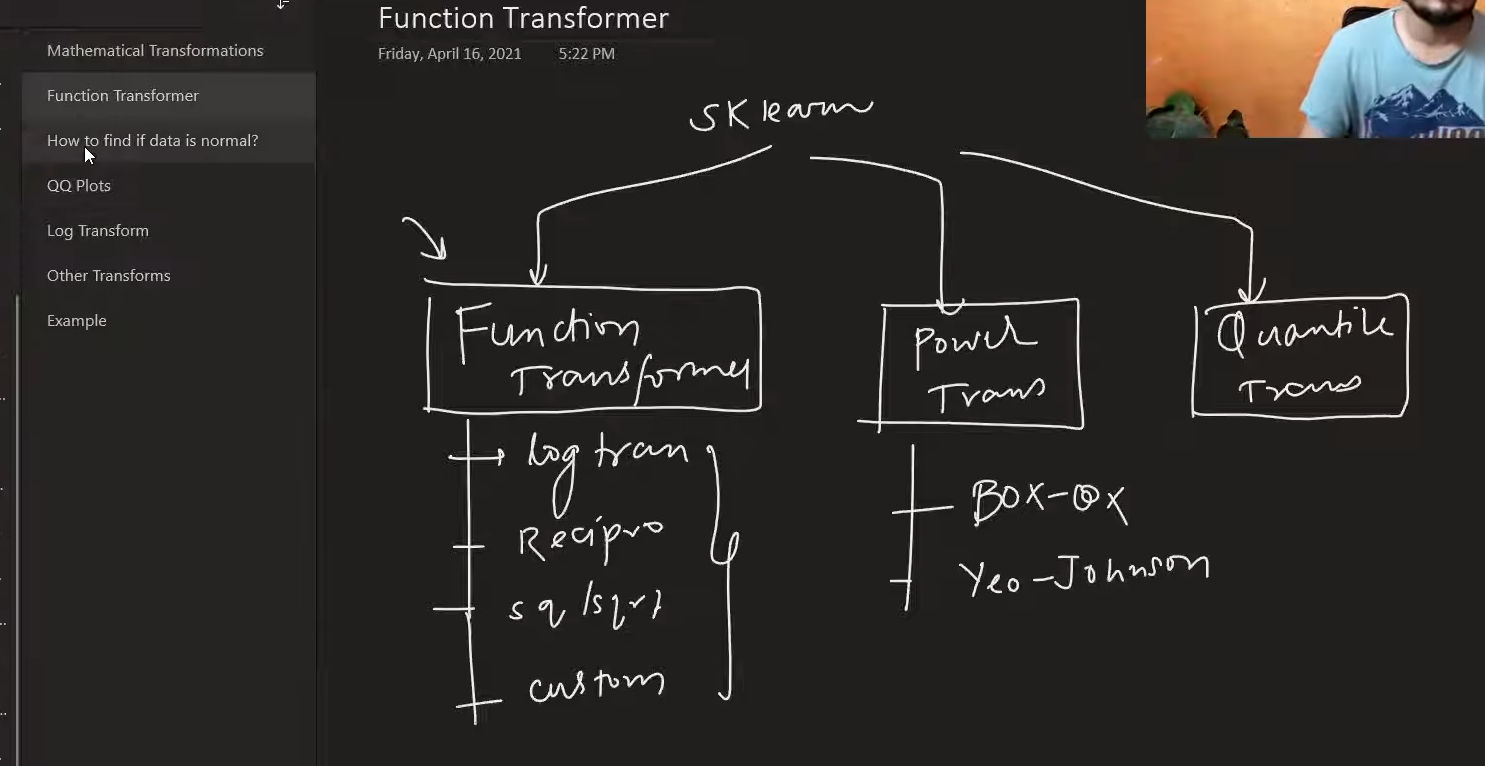

# How to find if data is normal 

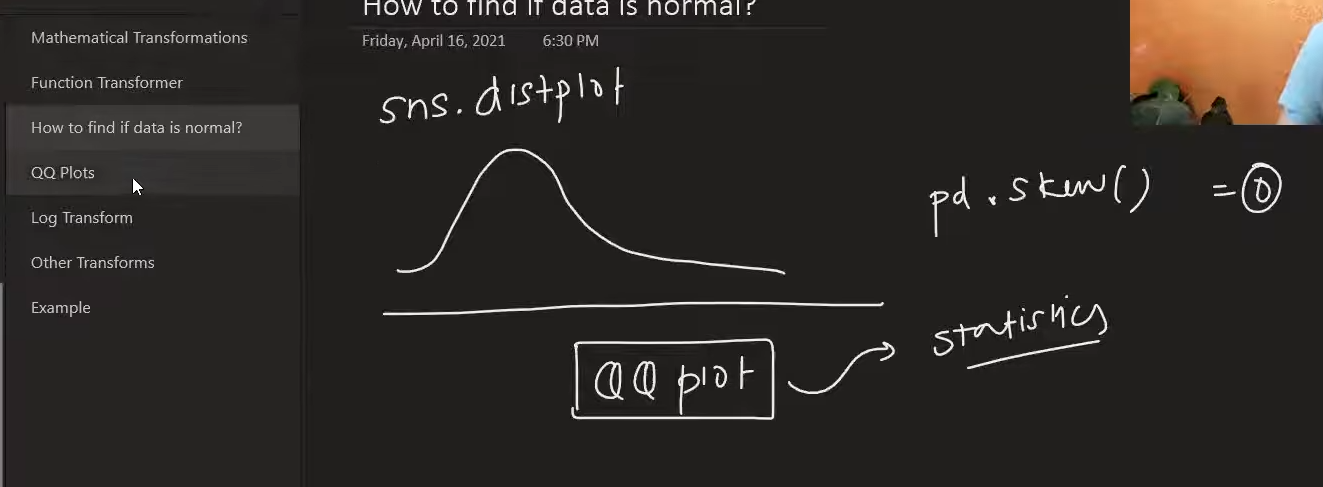

we use 
* distplot
* 
* skew = if skew is zero
 skewness is between -0.5 and 0.5, the data is considered approximately
  symmetric (close enough to normal).
  If it's outside that range it is significantly skewed (not normal).
  
* qq plot

# qq plot
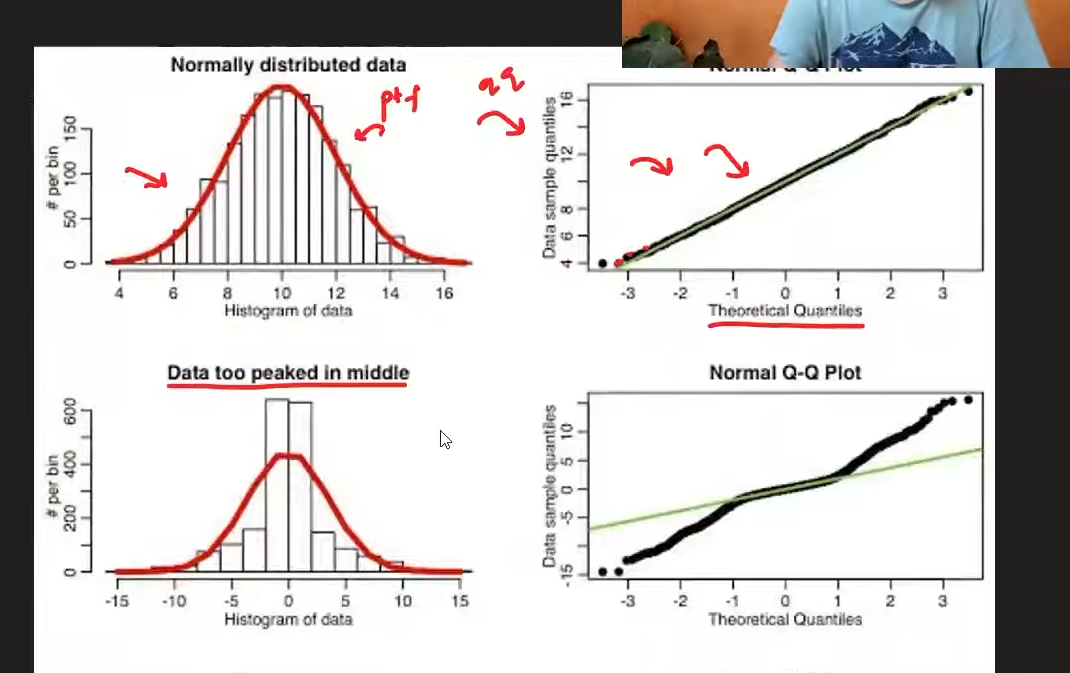
* if points are exactly on 45 degree line then data is normally distributed

* 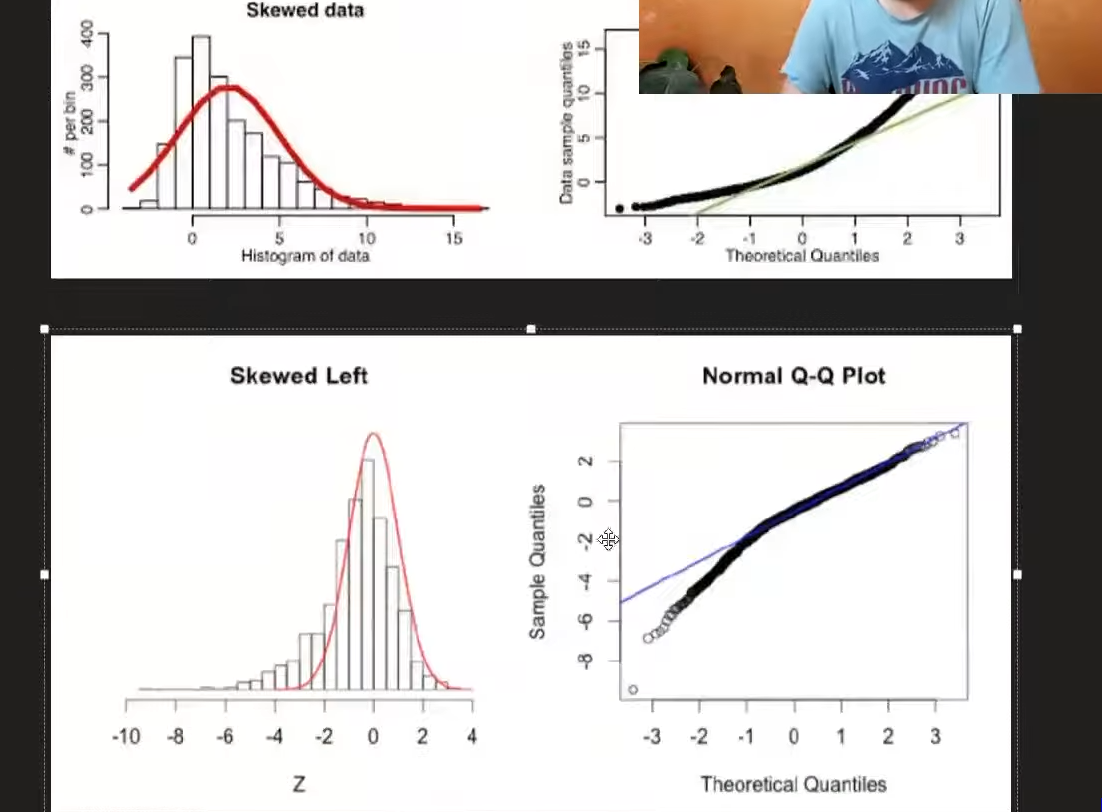


# Log Transform

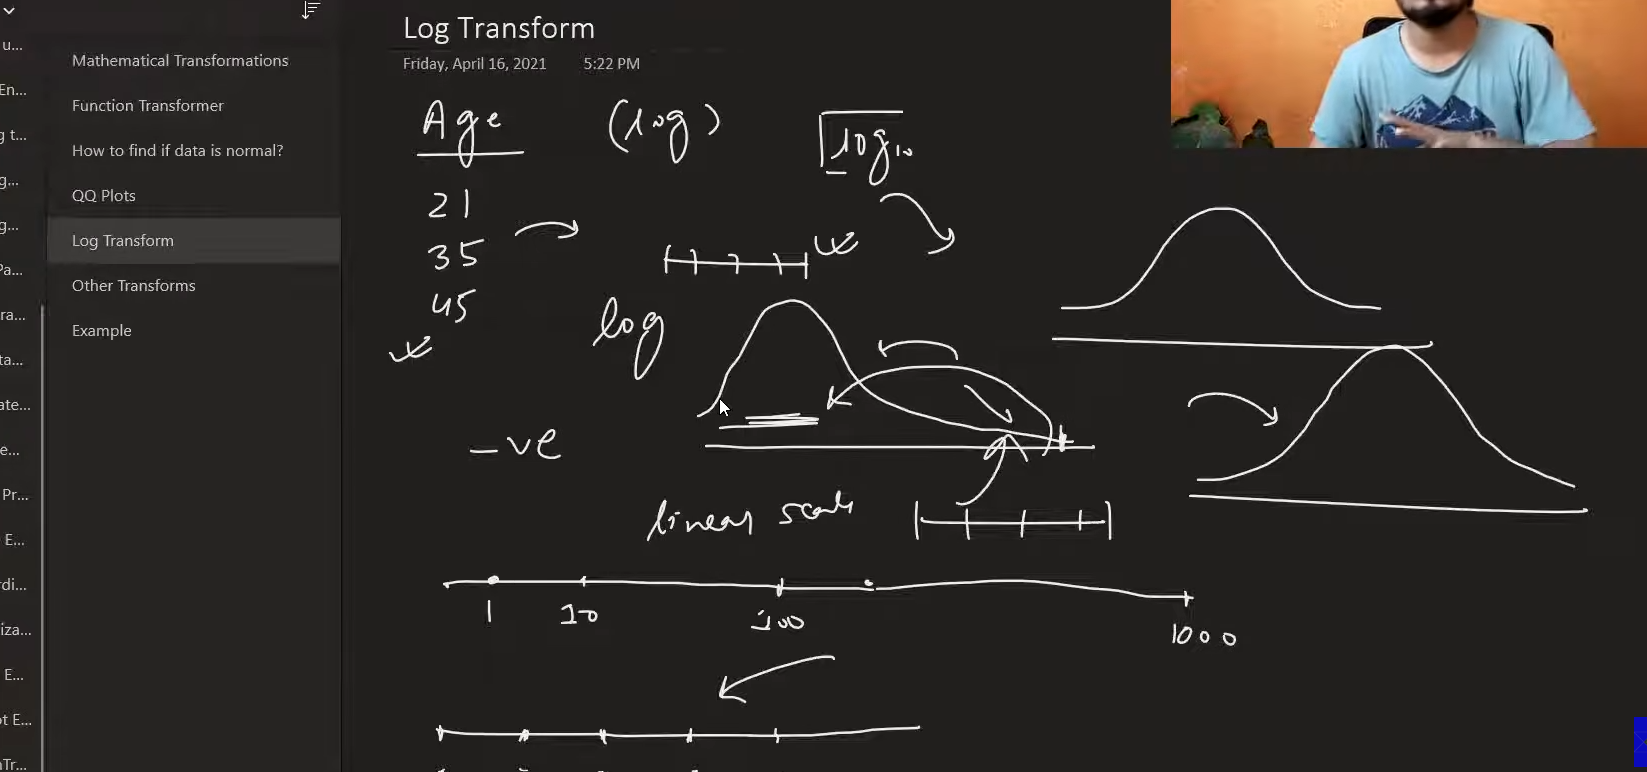

we take log of values after this data will be normally distributed(not 
completely but better than current state)
* it won't work on negative values.
* If u use log transformation on right Skew data then
it brings it to the centre.

* how log works = if we have a large data on linear scale so after log transformation
 it will come on equivalent scale and here linear models performance starts improving

# Other Transformation
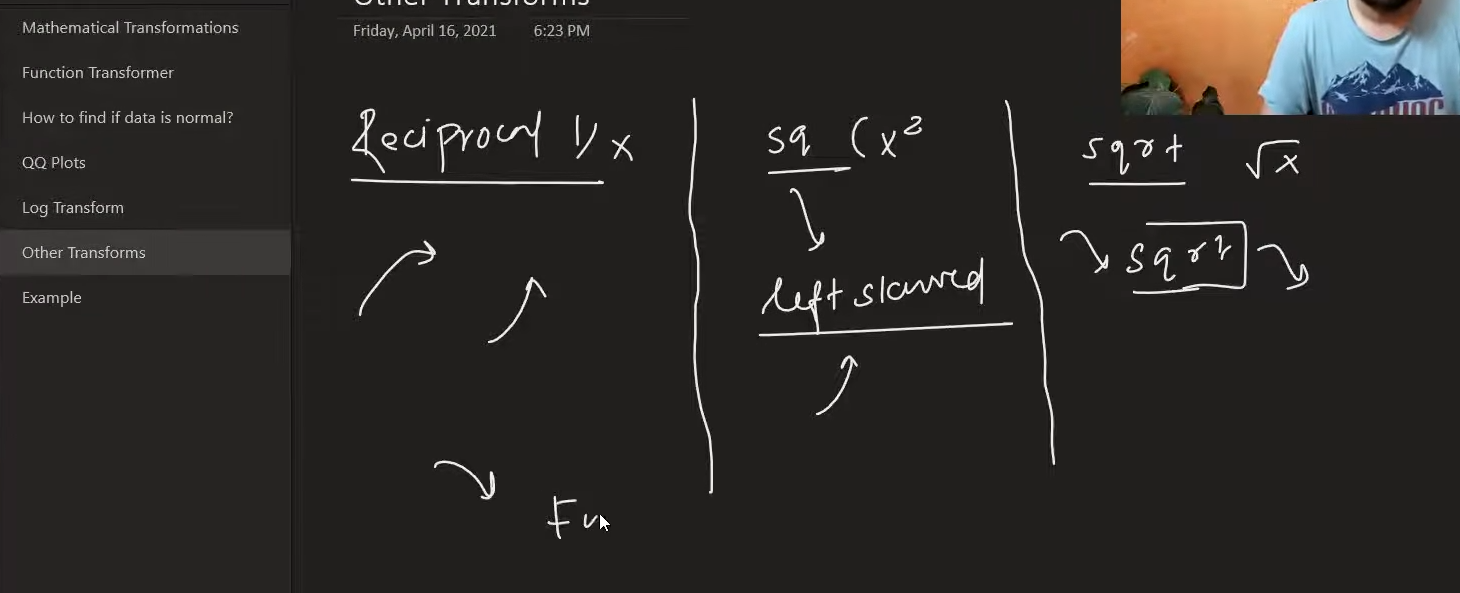

reciprocal =  it changes our small data into big and big into small

# Example

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import scipy.stats as stats

from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score
from sklearn.metrics import accuracy_score
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import FunctionTransformer
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import MinMaxScaler
from sklearn.pipeline import Pipeline , make_pipeline
from sklearn.feature_selection import SelectKBest,chi2
from sklearn.preprocessing import OneHotEncoder
from sklearn.tree import DecisionTreeClassifier

In [2]:
df = pd.read_csv('titanic.csv',usecols = ['Age','Fare', 'Survived'])

In [3]:
# df.isnull().sum()
df['Age'].fillna(df['Age'].mean(),inplace = True)
# df['Age'].isnull().sum()

C:\Users\Abhinav Harivanshi\AppData\Local\Temp\ipykernel_18828\2299378205.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Age'].fillna(df['Age'].mean(),inplace = True)


In [4]:
df.head()

,Survived,Age,Fare
0,0,22.0,7.2500
1,1,38.0,71.2833
2,1,26.0,7.9250
3,1,35.0,53.1000
4,0,35.0,8.0500


In [5]:
x = df.iloc[:,1:3]
y = df.iloc[:,0]

In [6]:
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size = 0.2,random_state = 42)

C:\Users\Abhinav Harivanshi\AppData\Local\Temp\ipykernel_18828\3116247987.py:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(x_train['Fare'])


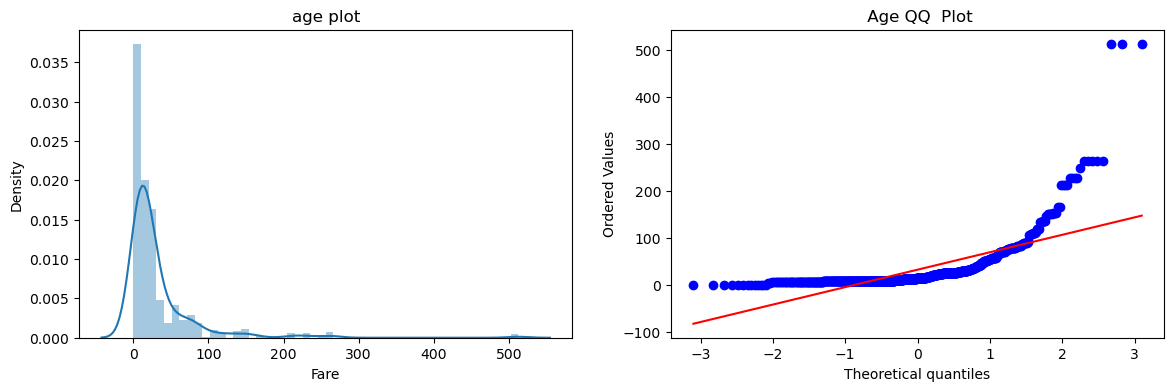

In [7]:
plt.figure(figsize = (14,4))
plt.subplot(121)
sns.distplot(x_train['Fare'])
plt.title('age plot')

plt.subplot(122)
stats.probplot(x_train['Fare'], dist ="norm", plot = plt)
plt.title(' Age QQ  Plot')
plt.show()

In [8]:
clf = LogisticRegression()
clf1 = DecisionTreeClassifier()

In [9]:
clf.fit(x_train , y_train)
clf1.fit(x_train, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [10]:
y_pred = clf.predict(x_test)
y_pred1 = clf1.predict(x_test)

In [11]:
print('accuracy of LR is', accuracy_score(y_test,y_pred))
print('accuracy of DT is', accuracy_score(y_test,y_pred1))

accuracy of LR is 0.6480446927374302
accuracy of DT is 0.664804469273743


In [12]:
trf = FunctionTransformer(func = np.log1p)
# nplogp = applies directly log but if there is zero then we can get error
# nplog1 = applies 1+log but if there is zero it will be 1 then we won't get any error


In [13]:
x_train_transformed = trf.fit_transform(x_train)
x_test_transformed = trf.transform(x_test)

In [14]:
clf = LogisticRegression()
clf1 = DecisionTreeClassifier()

In [15]:
clf.fit(x_train_transformed,y_train)
clf1.fit(x_train_transformed,y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [16]:
y_pred = clf.predict(x_test_transformed)
y_pred1 = clf1.predict(x_test_transformed)

In [17]:
print('accuracy LR', accuracy_score(y_pred,y_test)) # improvement 
print('accuracy DT', accuracy_score(y_pred1,y_test)) # coz no effect on decision tree     

accuracy LR 0.6815642458100558
accuracy DT 0.6983240223463687


In [18]:
x_transformed = trf.fit_transform(x)

clf = LogisticRegression()
clf1 = DecisionTreeClassifier()

print('LR', np.mean(cross_val_score(clf,x_transformed,y,scoring = "accuracy",cv = 10)))  
print('DT', np.mean(cross_val_score(clf1,x_transformed,y,scoring = "accuracy",cv = 10))) 





LR 0.678027465667915
DT 0.6588639200998753


Text(0.5, 1.0, ' Fare After log')

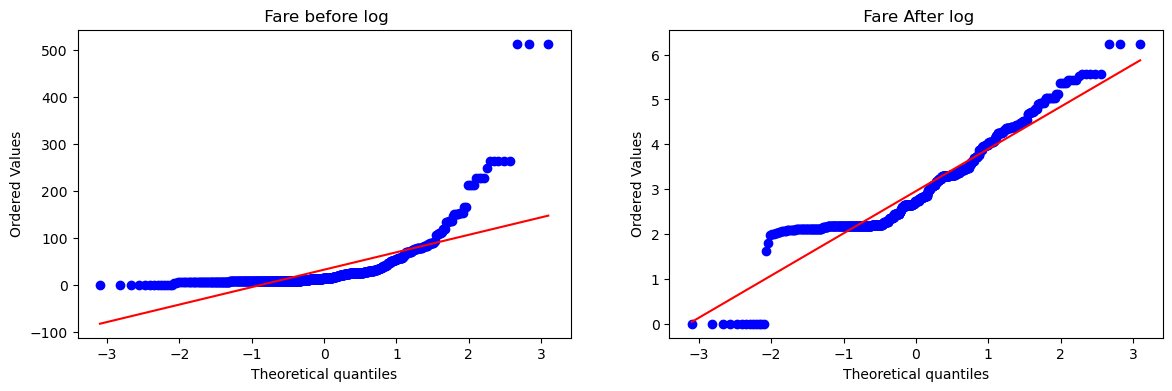

In [19]:
plt.figure(figsize = (14,4))
plt.subplot(121)
stats.probplot(x_train['Fare'], dist ="norm", plot = plt)
plt.title(' Fare before log')

plt.subplot(122)
stats.probplot(x_train_transformed['Fare'], dist ="norm", plot = plt)
plt.title(' Fare After log')

Text(0.5, 1.0, ' Age After log')

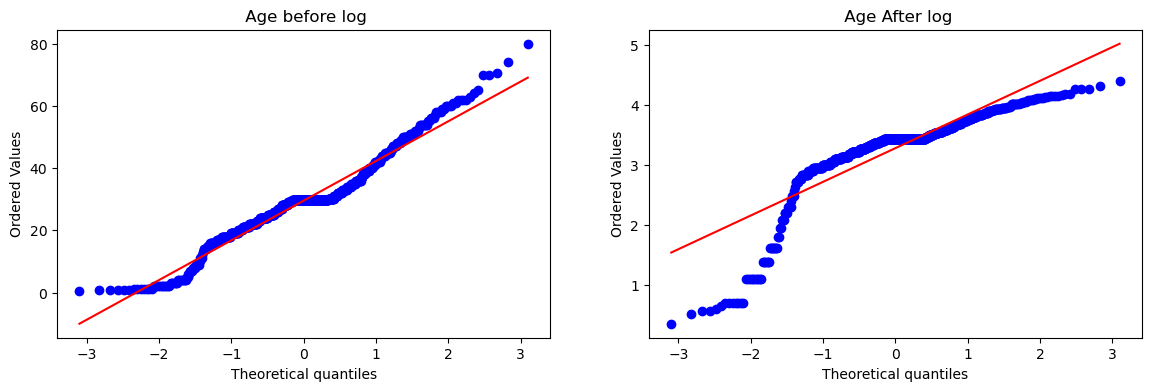

In [20]:
plt.figure(figsize = (14,4))
plt.subplot(121)
stats.probplot(x_train['Age'], dist ="norm", plot = plt)
plt.title(' Age before log')

plt.subplot(122)
stats.probplot(x_train_transformed['Age'], dist ="norm", plot = plt)
plt.title(' Age After log')

In [31]:
trf2 = ColumnTransformer([('log',FunctionTransformer(np.log1p),['Fare'])],remainder = 'passthrough')

x_train_transformed2 = trf2.fit_transform(x_train)
x_test_transformed2 = trf2.transform(x_test) 

In [32]:
clf = LogisticRegression()
clf1  = DecisionTreeClassifier()

In [33]:
clf.fit(x_train_transformed2,y_train)
clf1.fit(x_train_transformed2,y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [34]:
y_pred = clf.predict(x_test_transformed2)
y_pred2 = clf1.predict(x_test_transformed2)

In [35]:
print('accuracy of LR is', accuracy_score(y_test,y_pred))
print('accuracy of DT is', accuracy_score(y_test,y_pred2))

accuracy of LR is 0.6703910614525139
accuracy of DT is 0.6424581005586593


In [36]:
x_transformed2 = trf2.fit_transform(x)

clf = LogisticRegression()
clf2 = DecisionTreeClassifier()

print('LR', np.mean(cross_val_score(clf,x_transformed2,y,scoring = "accuracy",cv = 10)))  
print('DT', np.mean(cross_val_score(clf2,x_transformed2,y,scoring = "accuracy",cv = 10))) 




LR 0.6712609238451936
DT 0.6532459425717854


# Observation :
The data that was there in which age was already noramlly distributed 
fare was right skew so after applyin logtransformer on it result improved 
Decision tree has no effect coz decision tree is one ofthose algroith which has no effect what is the data distribution
linearregression , logisticregression has effect of log transformer

In [41]:
def apply_transform(transform):
    x = df.iloc[:,1:3]
    y = df.iloc[:,0]

    trf = ColumnTransformer([('log',FunctionTransformer(transform),['Fare'])],remainder = 'passthrough')

    x_trans = trf.fit_transform(x)

    clf = LogisticRegression()

    print('accuracy' , np.mean(cross_val_score(clf,x_trans,y,scoring = 'accuracy',cv = 10)))


    plt.figure(figsize = (14,4))
        
    plt.subplot(121)
    stats.probplot(x_train['Fare'], dist ="norm", plot = plt)
    plt.title(' Fare before transform')
        
    plt.subplot(122)
    stats.probplot(x_trans[:,0], dist ="norm", plot = plt)
    plt.title(' fare After transform')

                               
    plt.show()                           

    

accuracy 0.6589013732833957


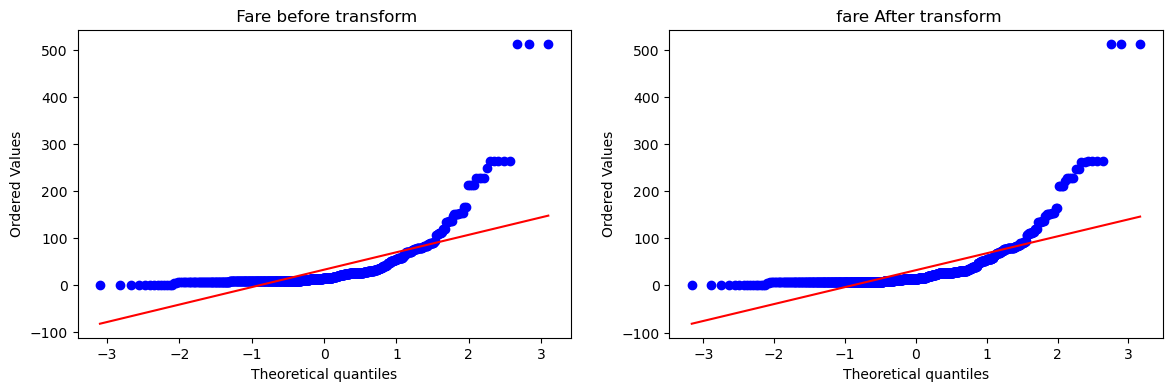

accuracy 0.6431335830212235


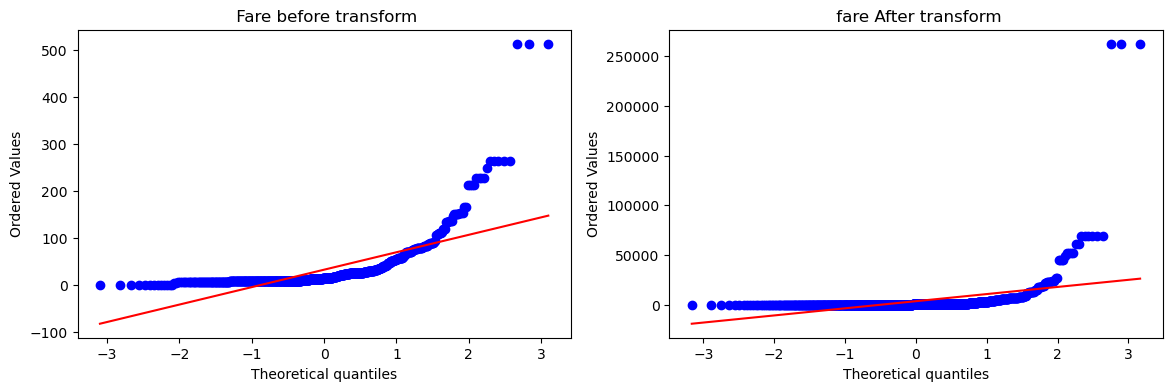

accuracy 0.61729088639201


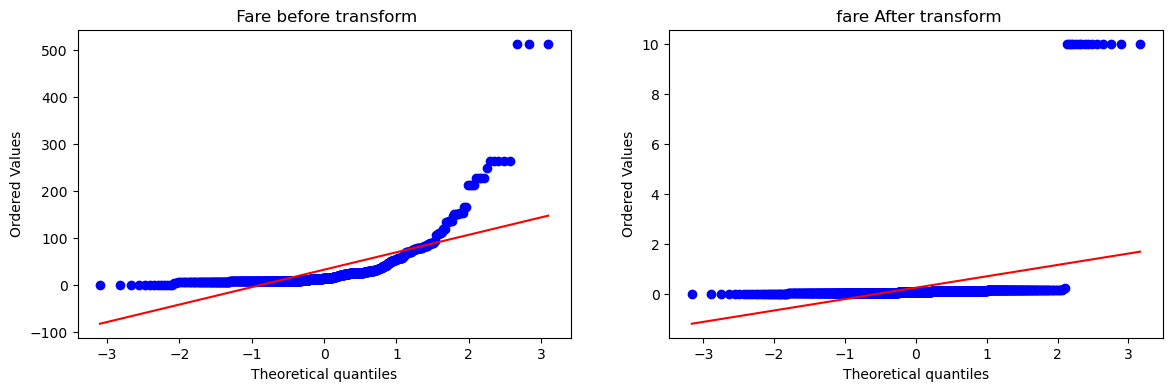

In [44]:
apply_transform(lambda x:x)
apply_transform(lambda x:x**2) # SQUARE
apply_transform(lambda x:1/(x+0.1)) #RECIPROCAL

